In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1: INSTALL DEPENDENCIES                                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

!pip install -q \
    transformers>=4.44.0 \
    accelerate>=0.33.0 \
    bitsandbytes>=0.43.0 \
    sentence-transformers>=3.0.0 \
    faiss-cpu \
    langgraph>=0.2.0 \
    langchain>=0.3.0 \
    langchain-community>=0.3.0 \
    langchain-huggingface>=0.1.0 \
    datasets>=2.20.0 \
    yfinance>=0.2.40 \
    plotly>=5.22.0 \
    kaleido \
    pandas \
    numpy \
    tqdm \
    huggingface_hub

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [ ]:
 #╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2: CONFIG & IMPORTS                                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os
import json
import time
import re
import warnings
from enum import Enum
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, Tuple, Any
from datetime import datetime, timedelta
from collections import Counter

import numpy as np
import pandas as pd
import torch
import faiss
import yfinance as yf
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from tqdm.auto import tqdm
from datasets import load_dataset

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

# ── Global Config ──
@dataclass
class Config:
    # Model
    llm_model_name: str = "Qwen/Qwen2.5-3B-Instruct"
    embed_model_name: str = "sentence-transformers/all-MiniLM-L6-v2"
    max_new_tokens: int = 1024
    temperature: float = 0.1

    # Data
    fnspid_dataset: str = "Zihan1004/FNSPID"
    demo_tickers: List[str] = field(default_factory=lambda: ["AAPL", "MSFT", "AMZN"])
    max_articles_per_ticker: int = 80
    chunk_size: int = 1500  # chars per chunk for LLM processing

    # Time ranges
    time_ranges: List[str] = field(default_factory=lambda: ["1W", "1M", "6M", "1Y"])

    # Vector store
    faiss_index_path: str = "/content/drive/MyDrive/MarketSensAI/vectorstore/"
    top_k_retrieval: int = 5

    # Output
    output_dir: str = "/content/drive/MyDrive/MarketSensAI/outputs/"

cfg = Config()

# Create output dirs
for d in [cfg.output_dir, cfg.faiss_index_path]:
    os.makedirs(d, exist_ok=True)

print("✅ Config ready")
print(f"   LLM: {cfg.llm_model_name}")
print(f"   Tickers: {cfg.demo_tickers}")
print(f"   Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ Config ready
   LLM: Qwen/Qwen2.5-3B-Instruct
   Tickers: ['AAPL', 'MSFT', 'AMZN']
   Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3: MILESTONE TAXONOMY & PROMPT TEMPLATES                         ║
# ╚══════════════════════════════════════════════════════════════════════════╝

class MilestoneType(Enum):
    FOUR_WEEK_HIGH = "4-Week High"
    FOUR_WEEK_LOW = "4-Week Low"
    FIFTY_TWO_WEEK_HIGH = "52-Week High"
    FIFTY_TWO_WEEK_LOW = "52-Week Low"
    SIXTEEN_MONTH_HIGH = "16-Month High"
    SIXTEEN_MONTH_LOW = "16-Month Low"
    ALL_TIME_HIGH = "All-Time High"
    ALL_TIME_LOW = "All-Time Low"
    BREAKOUT = "Breakout Event"

MILESTONE_LABELS = [m.value for m in MilestoneType]

# ── Prompt Templates ──

MILESTONE_EXTRACTION_PROMPT = """You are a financial analyst AI. Analyze the following news article about {ticker} and extract any financial milestones mentioned or implied.

Milestones to detect: {milestone_types}

Article:
\"\"\"
{article_text}
\"\"\"

Respond ONLY with valid JSON (no markdown, no explanation):
{{
  "milestones": [
    {{
      "type": "<milestone type from the list above>",
      "description": "<1-2 sentence description>",
      "confidence": <0.0-1.0>,
      "price_mentioned": "<price if mentioned, else null>",
      "date_mentioned": "<date if mentioned, else null>"
    }}
  ],
  "has_milestones": <true/false>
}}

If no milestones are found, return {{"milestones": [], "has_milestones": false}}"""

SENTIMENT_PROMPT = """You are a financial sentiment analyst. Score the following article about {ticker} on a bullish-bearish spectrum.

Article:
\"\"\"
{article_text}
\"\"\"

Respond ONLY with valid JSON:
{{
  "sentiment": "<bullish|bearish|neutral>",
  "score": <float from -1.0 (very bearish) to 1.0 (very bullish)>,
  "reasoning": "<1 sentence explanation>"
}}"""

REPORT_SYNTHESIS_PROMPT = """You are a financial report writer. Given the following extracted milestones and sentiment data for {ticker} over the time range {time_range}, produce a concise investor insight report.

Milestone Data:
{milestone_data}

Sentiment Summary:
{sentiment_data}

Write a structured insight report with these sections:
1. Executive Summary (2-3 sentences)
2. Key Milestones (bullet the most significant events)
3. Sentiment Overview (overall market mood)
4. Investor Takeaway (1-2 actionable sentences)

Keep it concise and professional."""

RAG_QA_PROMPT = """You are a financial Q&A assistant. Answer the user's question using ONLY the context provided below. If the context doesn't contain enough information, say so.

Context from retrieved articles:
{context}

Question: {question}

Provide a clear, concise answer grounded in the context above."""

LLM_JUDGE_PROMPT = """You are an evaluation judge. Rate the following AI-generated financial summary on three dimensions.

Original Articles (source):
{source_text}

Generated Summary:
{summary_text}

Rate each dimension from 1-5 and provide brief justification. Respond ONLY with valid JSON:
{{
  "hallucination": {{
    "score": <1=many hallucinations, 5=no hallucinations>,
    "justification": "<brief>"
  }},
  "faithfulness": {{
    "score": <1=unfaithful, 5=perfectly faithful>,
    "justification": "<brief>"
  }},
  "relevancy": {{
    "score": <1=irrelevant, 5=highly relevant>,
    "justification": "<brief>"
  }}
}}"""

print("✅ Taxonomy & prompts defined")
print(f"   {len(MILESTONE_LABELS)} milestone types")


✅ Taxonomy & prompts defined
   9 milestone types


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4: LOAD KAGGLE FINANCIAL NEWS DATASET                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("📥 Loading Financial News Dataset (Kaggle)...")
print("   Upload 'Financial_Sentiment_Categorized.csv' when prompted.\n")

from google.colab import files

# ── Step 1: Upload the CSV ──
csv_filename = "Financial_Sentiment_Categorized.csv"
if not os.path.exists(csv_filename):
    print("   ⬆️ Please upload the CSV file:")
    uploaded = files.upload()
    csv_filename = list(uploaded.keys())[0]
    print(f"   Uploaded: {csv_filename}")
else:
    print(f"   Found existing: {csv_filename}")

# ── Step 2: Load and explore ──
df_raw = pd.read_csv(csv_filename, on_bad_lines="skip", encoding_errors="replace")
print(f"\n   Rows: {len(df_raw):,}")
print(f"   Columns: {list(df_raw.columns)}")
print(f"   Categories: {df_raw['Category'].value_counts().head(5).to_dict()}")

# ── Step 3: Parse each article ──

COMPANY_TICKER_MAP = {
    "apple": "AAPL",
    "microsoft": "MSFT",
    "amazon": "AMZN",
}


def parse_article(row):
    """Parse the structured Content field into components."""
    title = str(row.get("Title", ""))
    content = str(row.get("Content", ""))
    tag = str(row.get("Tag", ""))
    category = str(row.get("Category", ""))

    # ── Extract ticker ──
    text_lower = (title + " " + content).lower()
    ticker = None
    for name, sym in sorted(COMPANY_TICKER_MAP.items(), key=lambda x: -len(x[0])):
        if name in text_lower:
            ticker = sym
            break

    # ── Extract date ──
    date_parsed = None
    # Try ISO timestamp (e.g., 2023-06-16T13:30:03.193)
    iso_match = re.search(r'(\d{4}-\d{2}-\d{2})T\d{2}:\d{2}:\d{2}', content)
    if iso_match:
        try:
            date_parsed = datetime.strptime(iso_match.group(1), "%Y-%m-%d")
        except ValueError:
            pass
    # Try relative date ("18 days ago")
    if date_parsed is None:
        rel_match = re.search(r'(\d+)\s*days?\s*ago', content)
        if rel_match:
            days_ago = int(rel_match.group(1))
            date_parsed = datetime(2023, 6, 15) - timedelta(days=days_ago)

    # ── Extract price ──
    # Price comes before a date like "186.612023-06-16" so we need to stop before the year
    price = None
    price_match = re.search(r'(?:high|low)\s+of\s+(\d{1,6}\.\d{1,4})(?=\d{4}-|\d+\s*day|$|\s)', content)
    if price_match:
        try:
            price = float(price_match.group(1).replace(",", ""))
        except ValueError:
            pass

    # ── Extract milestone type from title ──
    milestone_hint = None
    tl = title.lower()
    if "all-time high" in tl:
        milestone_hint = "All-Time High"
    elif "all-time low" in tl:
        milestone_hint = "All-Time Low"
    elif re.search(r'5[0-3]-week high', tl):
        milestone_hint = "52-Week High"
    elif re.search(r'5[0-3]-week low', tl):
        milestone_hint = "52-Week Low"
    elif re.search(r'(\d+)-week high', tl):
        wk = int(re.search(r'(\d+)-week high', tl).group(1))
        milestone_hint = "4-Week High" if wk <= 8 else "16-Month High"
    elif re.search(r'(\d+)-week low', tl):
        wk = int(re.search(r'(\d+)-week low', tl).group(1))
        milestone_hint = "4-Week Low" if wk <= 8 else "16-Month Low"
    elif "breakout" in tl:
        milestone_hint = "Breakout Event"

    # ── Clean content ──
    clean = content
    # Remove title prefix
    if title and content.startswith(title):
        clean = content[len(title):]
    # Remove "United States" and encoding artifacts
    clean = re.sub(r'^United States\s*[^\w]*\s*', '', clean)
    # Remove tag prefix
    if tag and tag.lower() in clean[:50].lower():
        idx = clean.lower().find(tag.lower())
        clean = clean[idx + len(tag):]
    # Remove trailing timestamp
    clean = re.sub(r'\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}[\d.]*', '', clean)
    clean = re.sub(r'\d+\s*days?\s*ago', '', clean)
    clean = clean.strip()

    return pd.Series({
        "ticker": ticker,
        "title": title,
        "content": content,
        "content_clean": clean if len(clean) > 20 else content,
        "date": date_parsed.strftime("%Y-%m-%d") if date_parsed else "unknown",
        "parsed_date": date_parsed,
        "price": price,
        "milestone_hint": milestone_hint,
        "category": category,
        "tag": tag,
    })


print("\n   Parsing all articles...")
parsed = df_raw.apply(parse_article, axis=1)

print(f"   Tickers extracted: {parsed['ticker'].notna().sum():,}/{len(parsed):,}")
print(f"   Dates extracted: {parsed['parsed_date'].notna().sum():,}/{len(parsed):,}")
print(f"   Prices extracted: {parsed['price'].notna().sum():,}/{len(parsed):,}")
print(f"   Milestones in title: {parsed['milestone_hint'].notna().sum():,}/{len(parsed):,}")

# ── Step 4: Filter to our 3 tickers and sample ──
ticker_set = set(cfg.demo_tickers)
df_filtered = parsed[parsed["ticker"].isin(ticker_set)].copy()

print(f"\n   Ticker distribution: {df_filtered['ticker'].value_counts().to_dict()}")

articles = []
ticker_counts = Counter()

for ticker in cfg.demo_tickers:
    df_t = df_filtered[df_filtered["ticker"] == ticker].copy()
    if df_t["parsed_date"].notna().any():
        df_t = df_t.sort_values("parsed_date", ascending=False)
    df_t = df_t.head(cfg.max_articles_per_ticker)

    for _, row in df_t.iterrows():
        articles.append(row.to_dict())
        ticker_counts[ticker] += 1

df_articles = pd.DataFrame(articles)

print(f"\n✅ Loaded {len(df_articles)} articles")
print(f"   Per ticker: {dict(ticker_counts)}")
print(f"   With dates: {df_articles['parsed_date'].notna().sum()}")
print(f"   With prices: {df_articles['price'].notna().sum()}")
print(f"   With milestone hints: {df_articles['milestone_hint'].notna().sum()}")

print(f"\n   Samples:")
for t in cfg.demo_tickers:
    sub = df_articles[df_articles["ticker"] == t]
    if len(sub) > 0:
        r = sub.iloc[0]
        print(f"   {t}: {r['title']} | Date: {r['date']} | Price: {r['price']} | Milestone: {r['milestone_hint']}")

df_articles.head()

📥 Loading Financial News Dataset (Kaggle)...
   Upload 'Financial_Sentiment_Categorized.csv' when prompted.

   ⬆️ Please upload the CSV file:


Saving Financial_Sentiment_Categorized.csv to Financial_Sentiment_Categorized.csv
   Uploaded: Financial_Sentiment_Categorized.csv

   Rows: 15,534
   Columns: ['Title', 'Tag', 'Content', 'Category']
   Categories: {'Market Indicators': 5708, 'Corporate Finance': 2775, 'Economic Health': 1213, 'Trade and Commerce': 1171, 'Credit and Lending': 1171}

   Parsing all articles...
   Tickers extracted: 501/15,534
   Dates extracted: 15,534/15,534
   Prices extracted: 642/15,534
   Milestones in title: 1,127/15,534

   Ticker distribution: {'AAPL': 211, 'MSFT': 170, 'AMZN': 120}

✅ Loaded 240 articles
   Per ticker: {'AAPL': 80, 'MSFT': 80, 'AMZN': 80}
   With dates: 240
   With prices: 30
   With milestone hints: 27

   Samples:
   AAPL: Apple Hits All-time High | Date: 2023-06-16 | Price: 186.61 | Milestone: All-Time High
   MSFT: US Stocks End Lower, Mark Best Week Since March | Date: 2023-06-16 | Price: nan | Milestone: None
   AMZN: Amazon Hits 30-week High | Date: 2023-05-26 | Price: 1

,ticker,title,content,content_clean,date,parsed_date,price,milestone_hint,category,tag
0,AAPL,Apple Hits All-time High,Apple Hits All-time HighUnited States stocksAp...,Apple increased to an all-time high of 186.61,2023-06-16,2023-06-16,186.61,All-Time High,Market Indicators,stocks
1,AAPL,Apple Hits All-time High,Apple Hits All-time HighUnited States stocksAp...,Apple increased to an all-time high of 184.96,2023-06-15,2023-06-15,184.96,All-Time High,Market Indicators,stocks
2,AAPL,US Futures Inch Lower After Lackluster Session,US Futures Inch Lower After Lackluster Session...,US stock futures inched lower on Tuesday after...,2023-06-06,2023-06-06,NaN,None,Market Indicators,Stock Market
3,AAPL,Apple Hits All-time High,Apple Hits All-time HighUnited States stocksAp...,Apple increased to an all-time high of 183.77,2023-06-05,2023-06-05,183.77,All-Time High,Market Indicators,stocks
4,AAPL,US Stocks End Mixed Ahead of Debt Ceiling Meeting,US Stocks End Mixed Ahead of Debt Ceiling Meet...,The Dow Jones closed 140 points lower on Monda...,2023-05-22,2023-05-22,NaN,None,Market Indicators,Stock Market


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5: STAGE 1 — DATA PIPELINE (CLEANING & UTILITY FUNCTIONS)        ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def clean_article(text):
    """Clean noisy article content."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def filter_by_time_range(df, ticker, time_range):
    """Filter articles by ticker. Falls back to all articles if date filter empties results."""
    df_t = df[df["ticker"] == ticker].copy()

    if "parsed_date" in df_t.columns and df_t["parsed_date"].notna().any():
        df_valid = df_t.dropna(subset=["parsed_date"])
        now = datetime.now()
        range_map = {
            "1D": timedelta(days=1), "1W": timedelta(weeks=1),
            "1M": timedelta(days=30), "6M": timedelta(days=182),
            "1Y": timedelta(days=365), "5Y": timedelta(days=1825),
        }
        delta = range_map.get(time_range, timedelta(days=365))
        cutoff = now - delta
        df_valid = df_valid[df_valid["parsed_date"] >= cutoff]
        if len(df_valid) > 0:
            return df_valid.sort_values("parsed_date", ascending=False)

    # Fallback: return all articles for this ticker (no date filtering)
    return df_t


# ── Final verification ──
print("🧹 Final data verification...")

if "content_clean" not in df_articles.columns:
    df_articles["content_clean"] = df_articles["content"].apply(clean_article)

before = len(df_articles)
df_articles = df_articles[df_articles["content_clean"].astype(str).str.len() > 20]
print(f"✅ Data pipeline complete: {before} → {len(df_articles)} articles")

if "milestone_hint" in df_articles.columns:
    hints = df_articles["milestone_hint"].value_counts()
    print(f"\n📊 Pre-extracted milestone hints from titles:")
    print(hints.to_string())

print(f"\n📊 Articles per ticker:")
print(df_articles["ticker"].value_counts().to_string())

🧹 Final data verification...
✅ Data pipeline complete: 240 → 240 articles

📊 Pre-extracted milestone hints from titles:
milestone_hint
16-Month High    10
All-Time High     7
4-Week High       6
4-Week Low        4

📊 Articles per ticker:
ticker
AAPL    80
MSFT    80
AMZN    80


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6: LOAD LLM (Qwen 2.5 7B, 4-bit Quantized)                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print(f"🤖 Loading {cfg.llm_model_name} with 4-bit quantization...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(
    cfg.llm_model_name,
    trust_remote_code=True,
    padding_side="left",
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    cfg.llm_model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
)
model.eval()

print(f"✅ Model loaded on {model.device}")
print(f"   Memory: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated")


def generate(prompt: str, max_tokens: int = None) -> str:
    """Run inference with the local LLM."""
    max_tokens = max_tokens or cfg.max_new_tokens
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=4096).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=cfg.temperature,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
        )
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return response.strip()


def parse_json_response(text: str) -> dict:
    """Robustly extract JSON from LLM output."""
    # Try direct parse
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    # Try extracting JSON block
    patterns = [
        r'```json\s*(.*?)\s*```',
        r'```\s*(.*?)\s*```',
        r'(\{.*\})',
    ]
    for pattern in patterns:
        match = re.search(pattern, text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group(1))
            except json.JSONDecodeError:
                continue
    return {}


# Quick test
test_response = generate("What is 2+2? Reply with just the number.")
print(f"   Sanity check: 2+2 = {test_response}")

🤖 Loading Qwen/Qwen2.5-3B-Instruct with 4-bit quantization...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Model loaded on cuda:0
   Memory: 2.2 GB allocated
   Sanity check: 2+2 = 4


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7: LOAD EMBEDDING MODEL                                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print(f"📐 Loading embedding model: {cfg.embed_model_name}")
embed_model = SentenceTransformer(cfg.embed_model_name, device="cuda")
print(f"✅ Embedding model loaded (dim={embed_model.get_sentence_embedding_dimension()})")


📐 Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Embedding model loaded (dim=384)


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8: STAGE 2 — AGENT IMPLEMENTATIONS                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ── Agent 1: News Retrieval Agent ──
class NewsRetrievalAgent:
    """Fetches and filters articles by ticker + time range."""

    def __init__(self, df: pd.DataFrame):
        self.df = df

    def retrieve(self, ticker: str, time_range: str) -> pd.DataFrame:
        filtered = filter_by_time_range(self.df, ticker, time_range)
        print(f"   📰 NewsRetrieval: {len(filtered)} articles for {ticker} ({time_range})")
        return filtered


# ── Agent 2: Milestone Extraction Agent ──
class MilestoneExtractionAgent:
    """Extracts financial milestones from article text using LLM."""

    def extract(self, ticker: str, articles: pd.DataFrame) -> List[Dict]:
        all_milestones = []
        for _, row in tqdm(articles.iterrows(), total=len(articles), desc=f"   🏔️ Milestones ({ticker})"):
            prompt = MILESTONE_EXTRACTION_PROMPT.format(
                ticker=ticker,
                milestone_types=", ".join(MILESTONE_LABELS),
                article_text=row["content_clean"][:cfg.chunk_size],
            )
            response = generate(prompt, max_tokens=512)
            parsed = parse_json_response(response)

            if parsed.get("has_milestones") and parsed.get("milestones"):
                for m in parsed["milestones"]:
                    m["source_date"] = row["date"]
                    m["source_title"] = row.get("title", "")
                    m["ticker"] = ticker
                    all_milestones.append(m)

        print(f"   ✅ Extracted {len(all_milestones)} milestones for {ticker}")
        return all_milestones


# ── Agent 3: Sentiment Analysis Agent ──
class SentimentAgent:
    """Scores article sentiment on bullish-bearish spectrum."""

    def analyze(self, ticker: str, articles: pd.DataFrame) -> List[Dict]:
        sentiments = []
        for _, row in tqdm(articles.iterrows(), total=len(articles), desc=f"   🎯 Sentiment ({ticker})"):
            prompt = SENTIMENT_PROMPT.format(
                ticker=ticker,
                article_text=row["content_clean"][:cfg.chunk_size],
            )
            response = generate(prompt, max_tokens=256)
            parsed = parse_json_response(response)

            if parsed:
                parsed["source_date"] = row["date"]
                parsed["ticker"] = ticker
                sentiments.append(parsed)
            else:
                sentiments.append({
                    "sentiment": "neutral",
                    "score": 0.0,
                    "reasoning": "Could not parse",
                    "source_date": row["date"],
                    "ticker": ticker,
                })

        print(f"   ✅ Scored {len(sentiments)} articles for {ticker}")
        return sentiments


# ── Agent 4: Report Synthesis Agent ──
class ReportSynthesisAgent:
    """Compiles milestones + sentiment into insight report."""

    def synthesize(self, ticker: str, time_range: str,
                   milestones: List[Dict], sentiments: List[Dict]) -> str:
        # Summarize milestone data
        if milestones:
            milestone_summary = json.dumps(milestones[:15], indent=2, default=str)
        else:
            milestone_summary = "No milestones detected in this time range."

        # Summarize sentiment
        scores = [s.get("score", 0) for s in sentiments if isinstance(s.get("score"), (int, float))]
        avg_score = np.mean(scores) if scores else 0.0
        sent_counts = Counter(s.get("sentiment", "neutral") for s in sentiments)
        sentiment_summary = f"Average score: {avg_score:.2f} | Distribution: {dict(sent_counts)}"

        prompt = REPORT_SYNTHESIS_PROMPT.format(
            ticker=ticker,
            time_range=time_range,
            milestone_data=milestone_summary,
            sentiment_data=sentiment_summary,
        )
        report = generate(prompt, max_tokens=800)
        return report


print("✅ All 4 agents defined")


✅ All 4 agents defined


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9: LANGGRAPH ORCHESTRATOR                                        ║
# ╚══════════════════════════════════════════════════════════════════════════╝

from langgraph.graph import StateGraph, END
from typing import TypedDict

class AgentState(TypedDict):
    ticker: str
    time_range: str
    articles: Any           # pd.DataFrame
    milestones: List[Dict]
    sentiments: List[Dict]
    report: str
    metadata: Dict

# Instantiate agents
news_agent = NewsRetrievalAgent(df_articles)
milestone_agent = MilestoneExtractionAgent()
sentiment_agent = SentimentAgent()
report_agent = ReportSynthesisAgent()


def retrieve_news(state: AgentState) -> AgentState:
    articles = news_agent.retrieve(state["ticker"], state["time_range"])
    state["articles"] = articles
    state["metadata"]["article_count"] = len(articles)
    return state


def extract_milestones(state: AgentState) -> AgentState:
    t0 = time.time()
    milestones = milestone_agent.extract(state["ticker"], state["articles"])
    state["milestones"] = milestones
    state["metadata"]["milestone_time"] = time.time() - t0
    return state


def analyze_sentiment(state: AgentState) -> AgentState:
    t0 = time.time()
    sentiments = sentiment_agent.analyze(state["ticker"], state["articles"])
    state["sentiments"] = sentiments
    state["metadata"]["sentiment_time"] = time.time() - t0
    return state


def synthesize_report(state: AgentState) -> AgentState:
    t0 = time.time()
    report = report_agent.synthesize(
        state["ticker"], state["time_range"],
        state["milestones"], state["sentiments"],
    )
    state["report"] = report
    state["metadata"]["report_time"] = time.time() - t0
    state["metadata"]["total_time"] = (
        state["metadata"].get("milestone_time", 0) +
        state["metadata"].get("sentiment_time", 0) +
        state["metadata"].get("report_time", 0)
    )
    return state


# Build the graph
workflow = StateGraph(AgentState)
workflow.add_node("retrieve_news", retrieve_news)
workflow.add_node("extract_milestones", extract_milestones)
workflow.add_node("analyze_sentiment", analyze_sentiment)
workflow.add_node("synthesize_report", synthesize_report)

workflow.set_entry_point("retrieve_news")
workflow.add_edge("retrieve_news", "extract_milestones")
workflow.add_edge("extract_milestones", "analyze_sentiment")
workflow.add_edge("analyze_sentiment", "synthesize_report")
workflow.add_edge("synthesize_report", END)

graph = workflow.compile()
print("✅ LangGraph orchestrator compiled")


✅ LangGraph orchestrator compiled


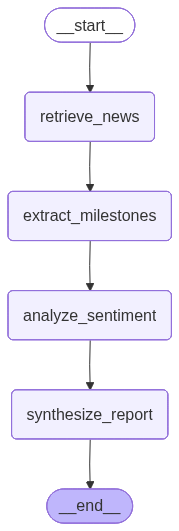

In [ ]:
from IPython.display import Image, display

# Requires pygraphviz or graphviz
display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10: RUN PIPELINE ON ALL DEMO TICKERS                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

all_results = {}

for ticker in cfg.demo_tickers:
    for tr in ["1Y"]:  # Run 1Y for poster; add more for full eval
        print(f"\n{'='*60}")
        print(f"🚀 Processing {ticker} | Time Range: {tr}")
        print(f"{'='*60}")

        initial_state: AgentState = {
            "ticker": ticker,
            "time_range": tr,
            "articles": pd.DataFrame(),
            "milestones": [],
            "sentiments": [],
            "report": "",
            "metadata": {},
        }

        result = graph.invoke(initial_state)

        key = f"{ticker}_{tr}"
        all_results[key] = {
            "ticker": ticker,
            "time_range": tr,
            "milestones": result["milestones"],
            "sentiments": result["sentiments"],
            "report": result["report"],
            "metadata": result["metadata"],
        }

        print(f"\n📋 Report for {ticker} ({tr}):")
        print("-" * 40)
        print(result["report"][:500])
        print("..." if len(result["report"]) > 500 else "")

# Save results
with open(os.path.join(cfg.output_dir, "pipeline_results.json"), "w") as f:
    json.dump(all_results, f, indent=2, default=str)

print(f"\n✅ All tickers processed. Results saved to {cfg.output_dir}")



🚀 Processing AAPL | Time Range: 1Y
   📰 NewsRetrieval: 80 articles for AAPL (1Y)


   🏔️ Milestones (AAPL):   0%|          | 0/80 [00:00<?, ?it/s]

   ✅ Extracted 79 milestones for AAPL


   🎯 Sentiment (AAPL):   0%|          | 0/80 [00:00<?, ?it/s]

   ✅ Scored 80 articles for AAPL

📋 Report for AAPL (1Y):
----------------------------------------
### Insight Report

#### Executive Summary
This report provides a comprehensive analysis of Apple Inc. (AAPL) stock performance over the past year, focusing on key milestones and overall sentiment. The stock has experienced several significant highs and lows, reflecting both bullish and bearish sentiments among investors.

#### Key Milestones
- **All-Time High**: Reached 186.61 on June 16, 2023.
- **All-Time High**: Reached 184.96 on June 15, 2023.
- **16-Month Low**: Stock fell 0.8% on June 6, 
...

🚀 Processing MSFT | Time Range: 1Y
   📰 NewsRetrieval: 80 articles for MSFT (1Y)


...

   ✅ Scored 80 articles for MSFT

📋 Report for MSFT (1Y):
----------------------------------------
### Insight Report

#### Executive Summary
Microsoft (MSFT) has experienced several significant price movements over the past year, including multiple 16-month highs and one All-Time High. The stock has also shown volatility, with notable 16-month lows and occasional 4-week lows. Despite this, the overall sentiment remains bullish, indicating investor confidence in the company's performance.

#### Key Milestones
- **16-Month High**: Microsoft reached a 16-month high at $338.57 on June 14, 2023.

...

🚀 Processing AMZN | Time Range: 1Y
   📰 NewsRetrieval: 80 articles for AMZN (1Y)


   🏔️ Milestones (AMZN):   0%|          | 0/80 [00:00<?, ?it/s]

   ✅ Extracted 80 milestones for AMZN


   🎯 Sentiment (AMZN):   0%|          | 0/80 [00:00<?, ?it/s]

   ✅ Scored 80 articles for AMZN

📋 Report for AMZN (1Y):
----------------------------------------
### Insight Report

#### Executive Summary
The recent financial landscape for Amazon (AMZN) has been characterized by a series of price highs and lows, reflecting both bullish and bearish sentiments. Notably, AMZN has experienced several 16-month highs and lows, indicating a volatile market environment. The average sentiment score of 0.07 suggests a slightly bearish overall market mood.

#### Key Milestones
- **16-Month Highs**: AMZN saw multiple 16-month highs, including a surge of 1.96% on Apr
...

✅ All tickers processed. Results saved to /content/drive/MyDrive/MarketSensAI/outputs/


In [ ]:
 #╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11: STAGE 3 — VECTOR STORE + RAG Q&A                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("🗄️ Building vector store for RAG...")

# Prepare documents for embedding
documents = []
doc_metadata = []

for _, row in df_articles.iterrows():
    text = f"[{row['ticker']}] {row.get('title', '')} | {row['date']}\n{row['content_clean']}"
    documents.append(text[:1000])  # cap for embedding
    doc_metadata.append({
        "ticker": row["ticker"],
        "date": row["date"],
        "title": row.get("title", ""),
    })

# Embed all documents
print(f"   Embedding {len(documents)} documents...")
embeddings = embed_model.encode(documents, show_progress_bar=True, batch_size=64)
embeddings = np.array(embeddings).astype("float32")

# Build FAISS index
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # Inner product (cosine sim with normalized vecs)
faiss.normalize_L2(embeddings)
index.add(embeddings)

print(f"✅ FAISS index built: {index.ntotal} vectors, dim={dimension}")

# Save index
faiss.write_index(index, os.path.join(cfg.faiss_index_path, "articles.index"))


class RAGQAModule:
    """Agentic RAG for conversational Q&A over financial articles."""

    def __init__(self, index, documents, metadata, embed_model, top_k=5):
        self.index = index
        self.documents = documents
        self.metadata = metadata
        self.embed_model = embed_model
        self.top_k = top_k

    def retrieve(self, query: str, ticker: Optional[str] = None) -> List[Dict]:
        query_vec = self.embed_model.encode([query]).astype("float32")
        faiss.normalize_L2(query_vec)
        scores, indices = self.index.search(query_vec, self.top_k * 2)

        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx < 0:
                continue
            meta = self.metadata[idx]
            if ticker and meta["ticker"] != ticker:
                continue
            results.append({
                "text": self.documents[idx],
                "score": float(score),
                **meta,
            })
            if len(results) >= self.top_k:
                break
        return results

    def answer(self, question: str, ticker: Optional[str] = None) -> Dict:
        retrieved = self.retrieve(question, ticker)
        context = "\n\n---\n\n".join([r["text"] for r in retrieved])

        prompt = RAG_QA_PROMPT.format(context=context, question=question)
        answer = generate(prompt, max_tokens=512)

        return {
            "question": question,
            "answer": answer,
            "sources": [{"title": r.get("title"), "date": r.get("date"), "score": r["score"]} for r in retrieved],
        }


rag = RAGQAModule(index, documents, doc_metadata, embed_model, top_k=cfg.top_k_retrieval)

# Demo Q&A
print("\n💬 RAG Q&A Demo:")
demo_questions = [
    ("What milestones has AAPL hit recently?", "AAPL"),
    ("What is the market sentiment around TSLA?", "TSLA"),
    ("Has NVDA shown any breakout events?", "NVDA"),
]

qa_results = []
for q, t in demo_questions:
    print(f"\n   Q: {q}")
    result = rag.answer(q, ticker=t)
    print(f"   A: {result['answer'][:300]}")
    qa_results.append(result)

# Save Q&A results
with open(os.path.join(cfg.output_dir, "qa_results.json"), "w") as f:
    json.dump(qa_results, f, indent=2, default=str)

print("\n✅ RAG Q&A module ready")


🗄️ Building vector store for RAG...
   Embedding 240 documents...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

✅ FAISS index built: 240 vectors, dim=384

💬 RAG Q&A Demo:

   Q: What milestones has AAPL hit recently?
   A: AAPL has hit the following milestones recently:
- On June 15, 2023, it reached an all-time high of 184.96.
- On February 11, 2023, it reached an all-time high of 187.
- There is no other recent data provided in the given context.

   Q: What is the market sentiment around TSLA?
   A: The context provided does not contain any information about market sentiment around TSLA (Tesla Inc.). Therefore, I cannot provide an answer based on the given information.

   Q: Has NVDA shown any breakout events?
   A: Based on the provided context, there is no information about NVDA showing any breakout events. The context does not contain any data or details related to NVDA's performance or market movements.

✅ RAG Q&A module ready


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12: EVALUATION                                                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("📊 Running evaluation suite...\n")

eval_results = {}

# ── Eval 1: Milestone Accuracy (vs. yfinance ground truth) ──
print("── Milestone Accuracy ──")

def get_price_milestones(ticker: str, period: str = "1y") -> Dict:
    """Get actual price milestones from yfinance."""
    try:
        hist = yf.download(ticker, period=period, progress=False)
        if hist.empty:
            return {}
        close = hist["Close"].squeeze()
        return {
            "52_week_high": float(close.max()),
            "52_week_low": float(close.min()),
            "52_week_high_date": str(close.idxmax().date()) if hasattr(close.idxmax(), 'date') else str(close.idxmax()),
            "52_week_low_date": str(close.idxmin().date()) if hasattr(close.idxmin(), 'date') else str(close.idxmin()),
            "current_price": float(close.iloc[-1]),
            "period_return": float((close.iloc[-1] / close.iloc[0] - 1) * 100),
        }
    except Exception as e:
        print(f"   ⚠️ yfinance error for {ticker}: {e}")
        return {}

milestone_accuracy = {}
for ticker in cfg.demo_tickers:
    gt = get_price_milestones(ticker)
    key = f"{ticker}_1Y"
    extracted = all_results.get(key, {}).get("milestones", [])

    # Count milestone types extracted
    type_counts = Counter(m.get("type", "Unknown") for m in extracted)

    # Check if extracted milestones mention prices close to actuals
    price_matches = 0
    total_with_price = 0
    for m in extracted:
        price_str = m.get("price_mentioned")
        if price_str and gt:
            try:
                price = float(re.sub(r'[^0-9.]', '', str(price_str)))
                total_with_price += 1
                # Check if within 10% of any actual milestone
                for gt_price in [gt.get("52_week_high", 0), gt.get("52_week_low", 0)]:
                    if gt_price > 0 and abs(price - gt_price) / gt_price < 0.10:
                        price_matches += 1
                        break
            except (ValueError, TypeError):
                pass

    accuracy = price_matches / total_with_price if total_with_price > 0 else None
    milestone_accuracy[ticker] = {
        "ground_truth": gt,
        "extracted_count": len(extracted),
        "type_distribution": dict(type_counts),
        "price_accuracy": accuracy,
    }
    print(f"   {ticker}: {len(extracted)} milestones extracted | Types: {dict(type_counts)}")
    if gt:
        print(f"      GT 52W High: ${gt.get('52_week_high', 'N/A'):.2f} | Low: ${gt.get('52_week_low', 'N/A'):.2f}")

eval_results["milestone_accuracy"] = milestone_accuracy


# ── Eval 2: Time-to-Insight ──
print("\n── Time-to-Insight ──")
manual_baseline_minutes = 30  # estimated time to read articles manually

time_metrics = {}
for key, result in all_results.items():
    total_sec = result["metadata"].get("total_time", 0)
    article_count = result["metadata"].get("article_count", 0)
    time_metrics[key] = {
        "system_seconds": round(total_sec, 1),
        "manual_estimate_seconds": manual_baseline_minutes * 60,
        "speedup_factor": round((manual_baseline_minutes * 60) / total_sec, 1) if total_sec > 0 else None,
        "articles_processed": article_count,
    }
    print(f"   {key}: {total_sec:.0f}s system vs. ~{manual_baseline_minutes*60}s manual "
          f"({time_metrics[key].get('speedup_factor', 'N/A')}x speedup)")

eval_results["time_to_insight"] = time_metrics


# ── Eval 3: LLM-as-Judge ──
print("\n── LLM-as-Judge Quality Scoring ──")

judge_scores = {}
for key, result in all_results.items():
    if not result["report"]:
        continue

    # Get source articles for this ticker
    ticker = result["ticker"]
    source_articles = df_articles[df_articles["ticker"] == ticker]["content_clean"].head(5).tolist()
    source_text = "\n---\n".join(source_articles)[:3000]

    prompt = LLM_JUDGE_PROMPT.format(
        source_text=source_text,
        summary_text=result["report"][:2000],
    )
    judge_response = generate(prompt, max_tokens=512)
    parsed = parse_json_response(judge_response)

    if parsed:
        judge_scores[key] = {
            dim: parsed[dim] for dim in ["hallucination", "faithfulness", "relevancy"]
            if dim in parsed
        }
        scores_str = " | ".join(
            f"{d}: {parsed[d].get('score', 'N/A')}/5"
            for d in ["hallucination", "faithfulness", "relevancy"]
            if d in parsed
        )
        print(f"   {key}: {scores_str}")
    else:
        print(f"   {key}: Could not parse judge response")

eval_results["llm_judge"] = judge_scores


# ── Eval 4: Event Coverage ──
print("\n── Event Coverage ──")
coverage = {}
for key, result in all_results.items():
    milestones = result["milestones"]
    types_found = set(m.get("type", "") for m in milestones)
    coverage_pct = len(types_found) / len(MILESTONE_LABELS) * 100 if MILESTONE_LABELS else 0
    coverage[key] = {
        "types_found": list(types_found),
        "total_types": len(MILESTONE_LABELS),
        "coverage_pct": round(coverage_pct, 1),
    }
    print(f"   {key}: {len(types_found)}/{len(MILESTONE_LABELS)} types ({coverage_pct:.0f}% coverage)")

eval_results["event_coverage"] = coverage

# Save all eval results
with open(os.path.join(cfg.output_dir, "eval_results.json"), "w") as f:
    json.dump(eval_results, f, indent=2, default=str)

print(f"\n✅ Evaluation complete. Results saved to {cfg.output_dir}")

📊 Running evaluation suite...

── Milestone Accuracy ──
   AAPL: 15 milestones extracted | Types: {'All-Time High': 8, '16-Month High': 3, '4-Week High': 3, '4-Week Low': 1}
      GT 52W High: $285.92 | Low: $171.67
   MSFT: 10 milestones extracted | Types: {'All-Time High': 1, '16-Month High': 3, '12-Month High': 1, '4-Week Low': 2, '4-Week High': 3}
      GT 52W High: $539.83 | Low: $351.87
   AMZN: 8 milestones extracted | Types: {'16-Month High': 1, '4-Week High': 6, '4-Week Low': 1}
      GT 52W High: $254.00 | Low: $167.32

── Time-to-Insight ──
   AAPL_1Y: 466s system vs. ~1800s manual (3.9x speedup)
   MSFT_1Y: 448s system vs. ~1800s manual (4.0x speedup)
   AMZN_1Y: 435s system vs. ~1800s manual (4.1x speedup)

── LLM-as-Judge Quality Scoring ──
   AAPL_1Y: hallucination: 4/5 | faithfulness: 3/5 | relevancy: 4/5
   MSFT_1Y: hallucination: 3/5 | faithfulness: 4/5 | relevancy: 4/5
   AMZN_1Y: hallucination: 3/5 | faithfulness: 4/5 | relevancy: 4/5

── Event Coverage ──
   AAPL_1

In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13: POSTER-READY VISUALIZATIONS                                  ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("🎨 Generating poster visualizations...\n")
VIZ_DIR = os.path.join(cfg.output_dir, "visualizations")
os.makedirs(VIZ_DIR, exist_ok=True)

# ── VIZ 1: Sentiment Distribution by Ticker ──
sent_data = []
for key, result in all_results.items():
    for s in result["sentiments"]:
        sent_data.append({
            "ticker": result["ticker"],
            "sentiment": s.get("sentiment", "neutral"),
            "score": s.get("score", 0),
        })

if sent_data:
    df_sent = pd.DataFrame(sent_data)

    fig1 = px.histogram(
        df_sent, x="score", color="ticker",
        nbins=30, barmode="overlay",
        title="Sentiment Score Distribution by Ticker",
        labels={"score": "Sentiment Score (Bearish ← → Bullish)", "count": "Article Count"},
        color_discrete_sequence=px.colors.qualitative.Set2,
        opacity=0.7,
    )
    fig1.update_layout(
        template="plotly_white",
        font=dict(size=14),
        title_font_size=20,
        width=900, height=500,
    )
    # fig1.write_image(os.path.join(VIZ_DIR, "sentiment_distribution.png"), scale=3)
    fig1.show()
    print("   ✅ Sentiment distribution saved")

# ── VIZ 2: Milestone Type Heatmap ──
milestone_matrix = {}
for key, result in all_results.items():
    ticker = result["ticker"]
    for m in result["milestones"]:
        mtype = m.get("type", "Unknown")
        if ticker not in milestone_matrix:
            milestone_matrix[ticker] = Counter()
        milestone_matrix[ticker][mtype] += 1

if milestone_matrix:
    all_types = sorted(set(t for counts in milestone_matrix.values() for t in counts))
    tickers_list = sorted(milestone_matrix.keys())
    z_data = [[milestone_matrix.get(t, {}).get(mt, 0) for mt in all_types] for t in tickers_list]

    fig2 = go.Figure(data=go.Heatmap(
        z=z_data,
        x=all_types,
        y=tickers_list,
        colorscale="Reds",
        text=z_data,
        texttemplate="%{text}",
        textfont={"size": 14},
    ))
    fig2.update_layout(
        title="Milestone Extraction Heatmap (Type × Ticker)",
        template="plotly_white",
        font=dict(size=13),
        title_font_size=20,
        width=1000, height=450,
        xaxis_title="Milestone Type",
        yaxis_title="Ticker",
    )
    # fig2.write_image(os.path.join(VIZ_DIR, "milestone_heatmap.png"), scale=3)
    fig2.show()
    print("   ✅ Milestone heatmap saved")

# ── VIZ 3: LLM-as-Judge Radar Chart ──
if judge_scores:
    dims = ["hallucination", "faithfulness", "relevancy"]
    fig3 = go.Figure()

    for key, scores in judge_scores.items():
        vals = [scores.get(d, {}).get("score", 0) for d in dims]
        vals.append(vals[0])  # close the polygon
        fig3.add_trace(go.Scatterpolar(
            r=vals,
            theta=dims + [dims[0]],
            fill='toself',
            name=key,
            opacity=0.6,
        ))

    fig3.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 5])),
        title="LLM-as-Judge Quality Scores",
        template="plotly_white",
        font=dict(size=13),
        title_font_size=20,
        width=700, height=500,
    )
    # fig3.write_image(os.path.join(VIZ_DIR, "llm_judge_radar.png"), scale=3)
    fig3.show()
    print("   ✅ LLM-as-Judge radar saved")

# ── VIZ 4: Time-to-Insight Comparison ──
if time_metrics:
    tickers_bar = []
    system_times = []
    manual_times = []
    for key, tm in time_metrics.items():
        tickers_bar.append(key)
        system_times.append(tm["system_seconds"] / 60)  # to minutes
        manual_times.append(tm["manual_estimate_seconds"] / 60)

    fig4 = go.Figure(data=[
        go.Bar(name="MarketSensAI", x=tickers_bar, y=system_times,
               marker_color="#c8102e", text=[f"{t:.1f}m" for t in system_times], textposition="outside"),
        go.Bar(name="Manual Reading", x=tickers_bar, y=manual_times,
               marker_color="#cccccc", text=[f"{t:.0f}m" for t in manual_times], textposition="outside"),
    ])
    fig4.update_layout(
        barmode="group",
        title="Time-to-Insight: MarketSensAI vs Manual Reading",
        yaxis_title="Time (minutes)",
        template="plotly_white",
        font=dict(size=14),
        title_font_size=20,
        width=800, height=450,
    )
    # fig4.write_image(os.path.join(VIZ_DIR, "time_to_insight.png"), scale=3)
    fig4.show()
    print("   ✅ Time-to-insight chart saved")

# ── VIZ 5: Event Coverage Bar ──
if coverage:
    cov_tickers = list(coverage.keys())
    cov_pcts = [coverage[t]["coverage_pct"] for t in cov_tickers]
    cov_found = [len(coverage[t]["types_found"]) for t in cov_tickers]

    fig5 = go.Figure(data=[
        go.Bar(
            x=cov_tickers, y=cov_pcts,
            marker_color=["#c8102e" if p >= 50 else "#ff6b6b" for p in cov_pcts],
            text=[f"{p:.0f}% ({n}/{len(MILESTONE_LABELS)})" for p, n in zip(cov_pcts, cov_found)],
            textposition="outside",
        )
    ])
    fig5.update_layout(
        title="Event Coverage by Ticker (% of Milestone Types Detected)",
        yaxis_title="Coverage (%)",
        yaxis_range=[0, 110],
        template="plotly_white",
        font=dict(size=14),
        title_font_size=20,
        width=800, height=400,
    )
    # fig5.write_image(os.path.join(VIZ_DIR, "event_coverage.png"), scale=3)
    fig5.show()
    print("   ✅ Event coverage chart saved")

# ── VIZ 6: Sentiment Averages ──
if sent_data:
    avg_sent = df_sent.groupby("ticker")["score"].mean().reset_index()
    avg_sent.columns = ["Ticker", "Avg Sentiment"]

    colors = ["#15803d" if s > 0.1 else "#dc2626" if s < -0.1 else "#737373" for s in avg_sent["Avg Sentiment"]]

    fig6 = go.Figure(data=[
        go.Bar(
            x=avg_sent["Ticker"], y=avg_sent["Avg Sentiment"],
            marker_color=colors,
            text=[f"{s:.2f}" for s in avg_sent["Avg Sentiment"]],
            textposition="outside",
        )
    ])
    fig6.update_layout(
        title="Average Sentiment by Ticker",
        yaxis_title="Avg Sentiment Score",
        yaxis_range=[-1, 1],
        template="plotly_white",
        font=dict(size=14),
        title_font_size=20,
        width=700, height=400,
    )
    # fig6.write_image(os.path.join(VIZ_DIR, "avg_sentiment.png"), scale=3)
    fig6.show()
    print("   ✅ Average sentiment chart saved")


print(f"\n{'='*60}")
print(f"🎉 ALL DONE! Visualizations saved to: {VIZ_DIR}")
print(f"   Pipeline results: {cfg.output_dir}pipeline_results.json")
print(f"   Eval results:     {cfg.output_dir}eval_results.json")
print(f"   Q&A results:      {cfg.output_dir}qa_results.json")
print(f"{'='*60}")

# List all saved files
print("\n📁 Output files:")
for root, dirs, files in os.walk(cfg.output_dir):
    for file in files:
        path = os.path.join(root, file)
        size = os.path.getsize(path) / 1024
        print(f"   {path} ({size:.0f} KB)")

🎨 Generating poster visualizations...



   ✅ Sentiment distribution saved


   ✅ Milestone heatmap saved


   ✅ LLM-as-Judge radar saved


   ✅ Time-to-insight chart saved


   ✅ Event coverage chart saved


   ✅ Average sentiment chart saved

🎉 ALL DONE! Visualizations saved to: /content/drive/MyDrive/MarketSensAI/outputs/visualizations
   Pipeline results: /content/drive/MyDrive/MarketSensAI/outputs/pipeline_results.json
   Eval results:     /content/drive/MyDrive/MarketSensAI/outputs/eval_results.json
   Q&A results:      /content/drive/MyDrive/MarketSensAI/outputs/qa_results.json

📁 Output files:
   /content/drive/MyDrive/MarketSensAI/outputs/pipeline_results.json (87 KB)
   /content/drive/MyDrive/MarketSensAI/outputs/eval_results.json (5 KB)


In [ ]:
!pip install -U kaleido==0.2.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 30.3 MB/s eta 0:00:00
  Attempting uninstall: kaleido
    Found existing installation: kaleido 1.2.0
    Uninstalling kaleido-1.2.0:
      Successfully uninstalled kaleido-1.2.0
